# Data Collection (collecting data required for the project)

Data needed to be collected:

1. Stock price data  → MSFT, AAPL, SNE (Yahoo Finance)
2. FF5 factor data   → 5 factors daily (Ken French website)

Date range:

→ Train : Jan 3, 2000 – Dec 2, 2011

→ Valid  : Dec 5, 2011 – Nov 29, 2013

#### 1. Installing required libraries

In [1]:
!pip install yfinance pandas_datareader


[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: pip install --upgrade pip


#### 2.Downloading stock data

In [2]:
import pandas as pd
import yfinance as yf
import urllib.request
import zipfile
import time
from io import StringIO

In [3]:
import yfinance as yf
import pandas as pd
import os

# Set your working directory 
BASE_DIR = '/content/drive/MyDrive/portfolio_project'

# Define your tickers and date range based on your project requirements
tickers = ["MSFT", "AAPL", "SONY"] 
start_date = "2000-01-03"
end_date = "2013-11-29"

stock_data = {}

for ticker in tickers:
    csv_path = os.path.join(BASE_DIR, f"{ticker}.csv")
    print(f"Attempting to fetch {ticker} from Yahoo Finance...")
    
    try:
        # Attempt to download from Yahoo Finance
        df = yf.download(ticker, start=start_date, end=end_date, progress=False)
        
        # yfinance might return an empty dataframe if it fails silently
        if df.empty:
            raise ValueError("Downloaded DataFrame is empty.")
            
        # If successful, save it to the local Google Drive folder for future use
        df.to_csv(csv_path)
        print(f"  Success: Downloaded and saved {ticker}.csv to Drive.")
        stock_data[ticker] = df
        
    except Exception as e:
        print(f"  Download failed ({e}). Falling back to local file...")
        
        # If the API fails, try loading the previously saved CSV
        if os.path.exists(csv_path):
            df = pd.read_csv(csv_path, index_col=0, parse_dates=True)
            print(f"  Success: Loaded {ticker} from local CSV.")
            stock_data[ticker] = df
        else:
            print(f"  [!] Error: Could not find {ticker}.csv in {BASE_DIR}.")
            print("      Wait for the API rate limit to reset to perform the initial download.")

# Now you can proceed with your data collection and plotting using stock_data["MSFT"], etc.

Attempting to fetch MSFT from Yahoo Finance...
YF.download() has changed argument auto_adjust default to True



1 Failed download:
['MSFT']: YFRateLimitError('Too Many Requests. Rate limited. Try after a while.')


  Download failed (Downloaded DataFrame is empty.). Falling back to local file...
  [!] Error: Could not find MSFT.csv in /content/drive/MyDrive/portfolio_project.
      Wait for the API rate limit to reset to perform the initial download.
Attempting to fetch AAPL from Yahoo Finance...



1 Failed download:
['AAPL']: YFRateLimitError('Too Many Requests. Rate limited. Try after a while.')


  Download failed (Downloaded DataFrame is empty.). Falling back to local file...
  [!] Error: Could not find AAPL.csv in /content/drive/MyDrive/portfolio_project.
      Wait for the API rate limit to reset to perform the initial download.
Attempting to fetch SONY from Yahoo Finance...



1 Failed download:
['SONY']: YFRateLimitError('Too Many Requests. Rate limited. Try after a while.')


  Download failed (Downloaded DataFrame is empty.). Falling back to local file...
  [!] Error: Could not find SONY.csv in /content/drive/MyDrive/portfolio_project.
      Wait for the API rate limit to reset to perform the initial download.


In [4]:
import pandas as pd
import yfinance as yf
import urllib.request
import zipfile
import time
import os
from io import StringIO

def download_stock(ticker, start, end, retries=3):
    # 1. First, attempt to download from Yahoo Finance
    for attempt in range(retries):
        try:
            data = yf.download(ticker, start=start,
                               end=end, auto_adjust=True, progress=False)
            
            if data is not None and len(data) > 0:
                print(f"{ticker}: {len(data)} rows downloaded from Yahoo Finance")
                # Handle potential MultiIndex columns from recent yfinance updates
                if isinstance(data.columns, pd.MultiIndex):
                    if ticker in data.columns.get_level_values(1):
                        return data['Close'][ticker]
                return data['Close']
        except Exception as e:
            print(f"{ticker} attempt {attempt+1} failed: {e}")
            time.sleep(3)
            
    # 2. Fallback to local CSV if the download fails (e.g. Rate Limit)
    print(f"{ticker}: Download failed. Checking current directory for {ticker}.csv...")
    file_path = f"{ticker}.csv"
    
    if os.path.exists(file_path):
        print(f"--> Found {file_path} locally. Loading data...")
        try:
            # Reads the specific 2-row header format of your CSVs
            df = pd.read_csv(file_path, header=[0, 1], index_col=0, parse_dates=True)
            return df['Close'][ticker]
        except Exception as e:
            print(f"Error parsing {file_path}: {e}")
            return None
    else:
        print(f"--> Error: {file_path} not found in the current directory.")
        return None

# --- Execution ---
start = '2000-01-03'
end   = '2013-11-29'

msft = download_stock('MSFT', start, end)
aapl = download_stock('AAPL', start, end)
sony = download_stock('SONY', start, end)

# Rename and combine (Includes a safety check so the code doesn't crash if a file is missing)
if msft is not None and aapl is not None and sony is not None:
    msft.name = 'MSFT'
    aapl.name = 'AAPL'
    sony.name = 'SONY'
    prices = pd.concat([msft, aapl, sony], axis=1)
    
    print("\nSuccessfully loaded and combined prices!")
    print(f"Shape: {prices.shape}")
else:
    print("\nFailed to load one or more stocks. Please ensure the CSVs are in the same folder.")


1 Failed download:
['MSFT']: YFRateLimitError('Too Many Requests. Rate limited. Try after a while.')

1 Failed download:
['MSFT']: YFRateLimitError('Too Many Requests. Rate limited. Try after a while.')

1 Failed download:
['MSFT']: YFRateLimitError('Too Many Requests. Rate limited. Try after a while.')


MSFT: Download failed. Checking current directory for MSFT.csv...
--> Found MSFT.csv locally. Loading data...



1 Failed download:
['AAPL']: YFRateLimitError('Too Many Requests. Rate limited. Try after a while.')

1 Failed download:
['AAPL']: YFRateLimitError('Too Many Requests. Rate limited. Try after a while.')

1 Failed download:
['AAPL']: YFRateLimitError('Too Many Requests. Rate limited. Try after a while.')


AAPL: Download failed. Checking current directory for AAPL.csv...
--> Found AAPL.csv locally. Loading data...



1 Failed download:
['SONY']: YFRateLimitError('Too Many Requests. Rate limited. Try after a while.')

1 Failed download:
['SONY']: YFRateLimitError('Too Many Requests. Rate limited. Try after a while.')

1 Failed download:
['SONY']: YFRateLimitError('Too Many Requests. Rate limited. Try after a while.')


SONY: Download failed. Checking current directory for SONY.csv...
--> Found SONY.csv locally. Loading data...

Successfully loaded and combined prices!
Shape: (3499, 3)


In [5]:
returns = prices.pct_change().dropna()


#### 3.FF5 DATA

In [6]:
# Print first 10 and last 20 lines to see what's there
url = "https://mba.tuck.dartmouth.edu/pages/faculty/ken.french/ftp/F-F_Research_Data_5_Factors_2x3_daily_CSV.zip"
urllib.request.urlretrieve(url, "FF5_daily.zip")

with zipfile.ZipFile("FF5_daily.zip", 'r') as z:
    fname = z.namelist()[0]
    z.extractall(".")

with open(fname, 'r') as f:
    lines = f.readlines()

print("=== FIRST 10 LINES ===")
for i, line in enumerate(lines[:10]):
    print(f"{i}: {repr(line)}")

print("\n=== LAST 20 LINES ===")
for i, line in enumerate(lines[-20:]):
    print(f"{len(lines)-20+i}: {repr(line)}")

=== FIRST 10 LINES ===
0: 'This file was created by using the 202602 CRSP database.\n'
1: 'The Tbill return is the simple daily rate that, over the number of trading days\n'
2: 'compounds to 1-month TBill rate. The 1-month TBill rate data until 202405 are from Ibbotson Associates. Starting from 202406, the 1-month TBill rate is from ICE BofA US 1-Month Treasury Bill Index.\n'
3: '\n'
4: ',Mkt-RF,SMB,HML,RMW,CMA,RF\n'
5: '19630701,   -0.67,    0.00,   -0.34,   -0.01,    0.16,    0.01\n'
6: '19630702,    0.79,   -0.26,    0.26,   -0.07,   -0.20,    0.01\n'
7: '19630703,    0.63,   -0.17,   -0.09,    0.18,   -0.34,    0.01\n'
8: '19630705,    0.40,    0.08,   -0.27,    0.09,   -0.34,    0.01\n'
9: '19630708,   -0.63,    0.04,   -0.18,   -0.29,    0.14,    0.01\n'

=== LAST 20 LINES ===
15757: '20260203,   -0.77,    0.43,    2.01,   -0.50,    0.83,    0.01\n'
15758: '20260204,   -0.56,    0.06,    2.32,    2.24,    2.37,    0.01\n'
15759: '20260205,   -1.33,   -0.61,    0.95,    1.74,    0

Finding start AND end of actual data

In [7]:
start_line = 0
end_line = len(lines)

for i, line in enumerate(lines):
    stripped = line.strip()
    # Find where data starts
    if stripped and stripped[:4].isdigit() and start_line == 0:
        start_line = i
    # Find where footer starts (after data, non-numeric rows appear again)
    if start_line > 0 and stripped and not stripped[:4].isdigit():
        end_line = i
        break

print(f"Data starts at line: {start_line}")
print(f"Data ends at line:   {end_line}")
print(f"Total data lines:    {end_line - start_line}")

# Sampling a few lines to confirm
print("\nSample lines:")
for line in lines[start_line:start_line+3]:
    print(repr(line))

Data starts at line: 5
Data ends at line:   15776
Total data lines:    15771

Sample lines:
'19630701,   -0.67,    0.00,   -0.34,   -0.01,    0.16,    0.01\n'
'19630702,    0.79,   -0.26,    0.26,   -0.07,   -0.20,    0.01\n'
'19630703,    0.63,   -0.17,   -0.09,    0.18,   -0.34,    0.01\n'


In [8]:
from io import StringIO
import pandas as pd

# Header is at line 4, data starts at line 5
# Just reading directly with comma separator, skipping first 4 lines

ff_data = pd.read_csv(
    fname,
    skiprows=4,
    sep=',',
    names=['Date','Mkt-RF','SMB','HML','RMW','CMA','RF']
)

# Drop footer rows (non-numeric dates at end)
ff_data = ff_data[pd.to_numeric(ff_data['Date'], errors='coerce').notna()].copy()

# Parse date
ff_data['Date'] = pd.to_datetime(ff_data['Date'].astype(int).astype(str), format='%Y%m%d')
ff_data = ff_data.set_index('Date')
ff_data = ff_data.astype(float) / 100  # % to decimal

print(ff_data.head())
print(f"\nShape: {ff_data.shape}")  # should be ~15770 rows

            Mkt-RF     SMB     HML     RMW     CMA      RF
Date                                                      
1963-07-01 -0.0067  0.0000 -0.0034 -0.0001  0.0016  0.0001
1963-07-02  0.0079 -0.0026  0.0026 -0.0007 -0.0020  0.0001
1963-07-03  0.0063 -0.0017 -0.0009  0.0018 -0.0034  0.0001
1963-07-05  0.0040  0.0008 -0.0027  0.0009 -0.0034  0.0001
1963-07-08 -0.0063  0.0004 -0.0018 -0.0029  0.0014  0.0001

Shape: (15770, 6)


#### 4. Merge data

In [9]:
merged = returns.join(ff_data, how='inner')

print("Merged shape:", merged.shape)
print("\nColumns:", merged.columns.tolist())
print("\nFirst few rows:")
print(merged.head())
print("\nMissing values:")
print(merged.isnull().sum())

Merged shape: (3498, 9)

Columns: ['MSFT', 'AAPL', 'SONY', 'Mkt-RF', 'SMB', 'HML', 'RMW', 'CMA', 'RF']

First few rows:
                MSFT      AAPL      SONY  Mkt-RF     SMB     HML     RMW  \
Date                                                                       
2000-01-04 -0.033780 -0.084310 -0.023508 -0.0406  0.0034  0.0207  0.0053   
2000-01-05  0.010543  0.014633 -0.074074 -0.0009  0.0036 -0.0005  0.0045   
2000-01-06 -0.033498 -0.086538 -0.136000 -0.0074 -0.0004  0.0124  0.0064   
2000-01-07  0.013068  0.047369  0.085069  0.0321 -0.0089 -0.0157 -0.0083   
2000-01-10  0.007292 -0.017588  0.066667  0.0175  0.0043 -0.0135 -0.0220   

               CMA      RF  
Date                        
2000-01-04  0.0136  0.0002  
2000-01-05  0.0115  0.0002  
2000-01-06  0.0121  0.0002  
2000-01-07 -0.0100  0.0002  
2000-01-10 -0.0024  0.0002  

Missing values:
MSFT      0
AAPL      0
SONY      0
Mkt-RF    0
SMB       0
HML       0
RMW       0
CMA       0
RF        0
dtype: int64


In [10]:
# EXCESS RETURNS
merged['MSFT_excess'] = merged['MSFT'] - merged['RF']
merged['AAPL_excess'] = merged['AAPL'] - merged['RF']
merged['SONY_excess'] = merged['SONY'] - merged['RF']

# SPLIT
train = merged['2000-01-03':'2011-12-02'].dropna()
valid = merged['2011-12-05':'2013-11-29'].dropna()

print(f"Train shape: {train.shape}")
print(f"Valid shape: {valid.shape}")

Train shape: (2999, 12)
Valid shape: (499, 12)


#### Saving the train and validation files

In [11]:
import os
import sys

# ── DETECT ENVIRONMENT ─────────────────────────────────────
def is_colab():
    return 'google.colab' in sys.modules

if is_colab():
    from google.colab import drive
    drive.mount('/content/drive')
    BASE_DIR = '/content/drive/MyDrive/portfolio_project'
else:
    BASE_DIR = os.path.join(os.getcwd(), 'portfolio_project')

# Create folder if not exists
os.makedirs(BASE_DIR, exist_ok=True)
print(f"Using directory: {BASE_DIR}")

Using directory: /Users/aaronjasonbaptist/Documents/IIT Kharagpur/Academic/Semester 4/Deep Learning /Github/gru-portfolio-management-project-main/data/portfolio_project


In [12]:
def save_data(df, filename):
    path = os.path.join(BASE_DIR, filename)
    df.to_csv(path)
    print(f"Saved: {path}")

# Save
save_data(train, 'train_data.csv')
save_data(valid, 'valid_data.csv')

Saved: /Users/aaronjasonbaptist/Documents/IIT Kharagpur/Academic/Semester 4/Deep Learning /Github/gru-portfolio-management-project-main/data/portfolio_project/train_data.csv
Saved: /Users/aaronjasonbaptist/Documents/IIT Kharagpur/Academic/Semester 4/Deep Learning /Github/gru-portfolio-management-project-main/data/portfolio_project/valid_data.csv


#### Plotting Figure-4 and Figure-5 in research paper

In [13]:
train = pd.read_csv(os.path.join(BASE_DIR, 'train_data.csv'),
                    index_col='Date', parse_dates=True)
valid = pd.read_csv(os.path.join(BASE_DIR, 'valid_data.csv'),
                    index_col='Date', parse_dates=True)

print(f"Train: {train.shape}")
print(f"Valid: {valid.shape}")

Train: (2999, 12)
Valid: (499, 12)


Working Directory set to: /Users/aaronjasonbaptist/Documents/IIT Kharagpur/Academic/Semester 4/Deep Learning /Github/gru-portfolio-management-project-main/data
Attempting to fetch MSFT from Yahoo Finance...



1 Failed download:
['MSFT']: YFRateLimitError('Too Many Requests. Rate limited. Try after a while.')


  Successfully loaded /Users/aaronjasonbaptist/Documents/IIT Kharagpur/Academic/Semester 4/Deep Learning /Github/gru-portfolio-management-project-main/data/MSFT.csv from local storage.
Attempting to fetch AAPL from Yahoo Finance...



1 Failed download:
['AAPL']: YFRateLimitError('Too Many Requests. Rate limited. Try after a while.')


  Successfully loaded /Users/aaronjasonbaptist/Documents/IIT Kharagpur/Academic/Semester 4/Deep Learning /Github/gru-portfolio-management-project-main/data/AAPL.csv from local storage.
Attempting to fetch SONY from Yahoo Finance...



1 Failed download:
['SONY']: YFRateLimitError('Too Many Requests. Rate limited. Try after a while.')


  Successfully loaded /Users/aaronjasonbaptist/Documents/IIT Kharagpur/Academic/Semester 4/Deep Learning /Github/gru-portfolio-management-project-main/data/SONY.csv from local storage.


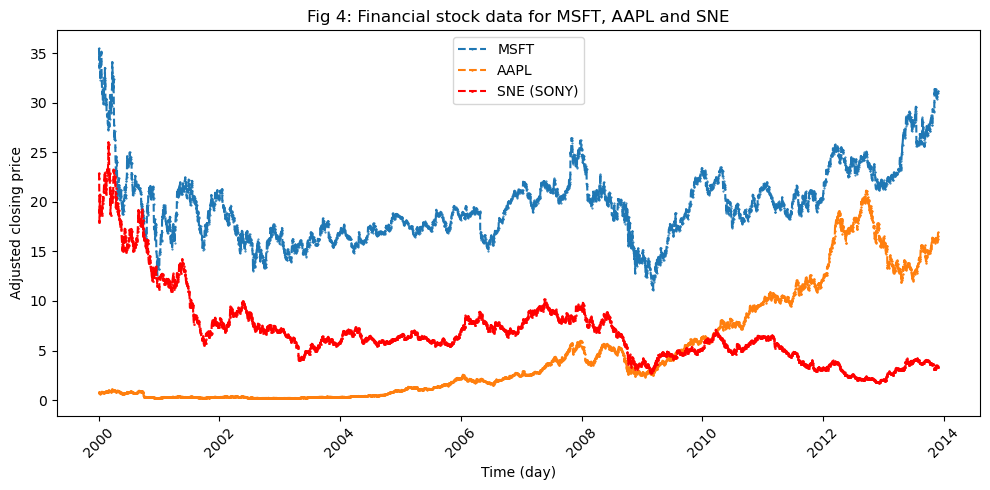

Process complete. Image saved to: /Users/aaronjasonbaptist/Documents/IIT Kharagpur/Academic/Semester 4/Deep Learning /Github/gru-portfolio-management-project-main/data/project_outputs/fig4_stock_prices.png


In [14]:
import os
import sys
import time
import pandas as pd
import yfinance as yf
import requests
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# 1. Universal Path Setup
if 'google.colab' in sys.modules:
    from google.colab import drive
    drive.mount('/content/drive')
    # Change this if your colab folder is named differently
    BASE_DIR = '/content/drive/MyDrive/portfolio_project'
else:
    # Dynamically find the folder where this script/notebook is located
    try:
        # Works for standard .py scripts
        BASE_DIR = os.path.dirname(os.path.abspath(__file__))
    except NameError:
        # Works for Jupyter Notebooks (.ipynb)
        BASE_DIR = os.getcwd()

print(f"Working Directory set to: {BASE_DIR}")

# 2. Setup Session to bypass basic rate limits
session = requests.Session()
session.headers.update({
    'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36'
})

def fetch_or_load_stock(ticker, start, end, retries=1):
    # Try downloading first
    for attempt in range(retries):
        try:
            print(f"Attempting to fetch {ticker} from Yahoo Finance...")
            data = yf.download(ticker, start=start, end=end, auto_adjust=True, progress=False, session=session)
            if data is not None and not data.empty:
                if isinstance(data.columns, pd.MultiIndex):
                    return data['Close'][ticker]
                return data['Close']
        except Exception as e:
            print(f"  Download failed. Falling back to local file...")
            break
            
    # Fallback to local file in the BASE_DIR
    file_path_upper = os.path.join(BASE_DIR, f"{ticker.upper()}.csv")
    file_path_lower = os.path.join(BASE_DIR, f"{ticker.lower()}.csv")
    
    # Check both uppercase and lowercase filenames
    actual_path = None
    if os.path.exists(file_path_upper):
        actual_path = file_path_upper
    elif os.path.exists(file_path_lower):
        actual_path = file_path_lower
        
    if actual_path:
        try:
            # Load with the multi-index headers that your CSVs use
            df = pd.read_csv(actual_path, header=[0, 1], index_col=0, parse_dates=True)
            print(f"  Successfully loaded {actual_path} from local storage.")
            return df['Close'][ticker.upper()]
        except Exception as e:
            print(f"  Error reading {actual_path}: {e}")
            return None
    else:
        print(f"  Error: Could not find {ticker}.csv in {BASE_DIR}.")
        return None

# 3. Execute Data Loading
start_date = '2000-01-03'
end_date = '2013-11-29'

msft_p = fetch_or_load_stock('MSFT', start_date, end_date)
aapl_p = fetch_or_load_stock('AAPL', start_date, end_date)
sony_p = fetch_or_load_stock('SONY', start_date, end_date)

# 4. Process and Plot
if msft_p is not None and aapl_p is not None and sony_p is not None:
    msft_p.name = 'MSFT'
    aapl_p.name = 'AAPL'
    sony_p.name = 'SONY'
    
    prices = pd.concat([msft_p, aapl_p, sony_p], axis=1)

    # Plotting
    fig, ax = plt.subplots(figsize=(10, 5))

    ax.plot(prices.index, prices['MSFT'], linestyle='--', marker='.', markersize=1, label='MSFT')
    ax.plot(prices.index, prices['AAPL'], linestyle='--', marker='+', markersize=1, label='AAPL')
    ax.plot(prices.index, prices['SONY'], linestyle='--', marker='^', markersize=1, label='SNE (SONY)', color='red')

    ax.set_xlabel('Time (day)')
    ax.set_ylabel('Adjusted closing price')
    ax.set_title('Fig 4: Financial stock data for MSFT, AAPL and SNE')
    ax.legend()
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.xaxis.set_major_locator(mdates.YearLocator(2))
    plt.xticks(rotation=45)
    plt.tight_layout()

    # Save output to a clean folder inside the current directory
    output_dir = os.path.join(BASE_DIR, 'project_outputs')
    os.makedirs(output_dir, exist_ok=True)
    fig4_path = os.path.join(output_dir, 'fig4_stock_prices.png')
    
    plt.savefig(fig4_path, dpi=150)
    plt.show()
    print(f"Process complete. Image saved to: {fig4_path}")
else:
    print("\n[!] Plotting failed due to missing data. Ensure the CSV files are in the same folder as this script.")

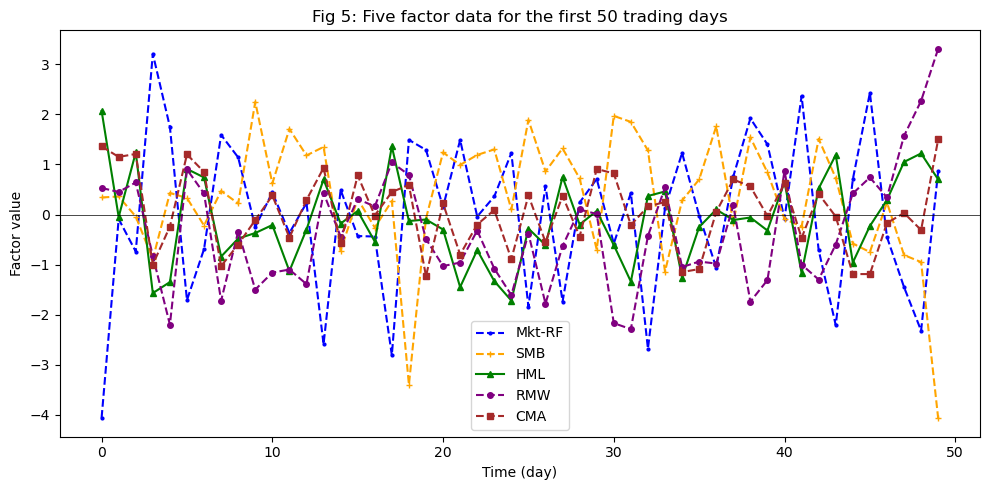

Saved: /Users/aaronjasonbaptist/Documents/IIT Kharagpur/Academic/Semester 4/Deep Learning /Github/gru-portfolio-management-project-main/data/fig5_five_factors.png


In [15]:
# Get first 50 rows of training data
feature_cols = ['Mkt-RF', 'SMB', 'HML', 'RMW', 'CMA']
ff_50 = train[feature_cols].iloc[:50]

# ── PLOT FIG 5 ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))

styles = [
    ('Mkt-RF', '--', '.', 'blue'),
    ('SMB',    '--', '+', 'orange'),
    ('HML',    '-',  '^', 'green'),
    ('RMW',    '--', 'o', 'purple'),
    ('CMA',    '--', 's', 'brown'),
]

for col, ls, marker, color in styles:
    ax.plot(range(50), ff_50[col] * 100,
            linestyle=ls, marker=marker,
            markersize=4, label=col, color=color)

ax.set_xlabel('Time (day)')
ax.set_ylabel('Factor value')
ax.set_title('Fig 5: Five factor data for the first 50 trading days')
ax.legend()
ax.axhline(y=0, color='black', linewidth=0.5)
plt.tight_layout()

# Save
fig5_path = os.path.join(BASE_DIR, 'fig5_five_factors.png')
plt.savefig(fig5_path, dpi=150)
plt.show()
print(f"Saved: {fig5_path}")